# Teoria de espalhamento para um material com simetria $\mathcal{PT}$


<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Cálculo-do-$n^2$" data-toc-modified-id="Cálculo-do-$n^2$-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Cálculo do $n^2$</a></span></li><li><span><a href="#Comportamento-do-máximo-da-distribuição-em-função-de-$\beta$" data-toc-modified-id="Comportamento-do-máximo-da-distribuição-em-função-de-$\beta$-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Comportamento do máximo da distribuição em função de $\beta$</a></span></li><li><span><a href="#$S_\beta(\omega)$-gráfico-polar" data-toc-modified-id="$S_\beta(\omega)$-gráfico-polar-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>$S_\beta(\omega)$ gráfico polar</a></span></li></ul></div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as sp
import scipy.constants as sc
import scipy.special as ss
from scipy.signal import argrelextrema
from numba import jit
%matplotlib inline

O código abaixo é apenas para usar $\LaTeX$ para renderizar os gráficos. Usando isso, eles ficam visualmente melhores.

In [2]:
def use_latex_render():
# Defino que o matplotlib deve usar o compilador do latex para renderizar os graficos
    plt.rc('text', usetex=True)
# Defino qual fonte quero usar.
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.sans-serif'] = ['Times']
# Coloco mudo o tamanho de todas as fontes
    plt.rcParams['font.size'] = 15
# Ajusto aqui o tamanho da legenda para ficar um pouco menor
    plt.rc('legend', fontsize = 12)
    plt.rcParams['figure.dpi'] = 150

Os parâmetros $\omega_0$, $\theta$, $\Gamma_0$, $\lambda_0$ e $\sigma$, foram retirados do paper do Wolf.

In [3]:
num_points = 1000
C = sc.c # m/s
OMEGA_0 = 3.427e15 # 10**15 s**-1
THETA = 24.9 # degrees
GAMMA_0 = 0.01 * OMEGA_0
LAMBDA_0 = 5.5e-7 # m
SIGMA = 3 * LAMBDA_0

In [4]:
def spectral_density_in(omega, gama):
    return np.exp(-0.5*((omega - 1) ** 2)/gama**2)

# Essa funcao segue a normalzicao criada pelo prof paulo. Nota que a normalizacao de S esta diferente do paper
@jit(nopython = True)
def norm_spectral_density(omega, theta, sigma, gamma, beta):
    theta_rad_by_2 = np.radians(theta)/ 2
    exponential = np.exp(-((omega - 1) **2)/ (2 * gamma **2) - (2 * sigma * omega * np.sin(theta_rad_by_2))**2)
    polynomial = 1 - 2 * omega * beta * (sigma * np.sin(theta_rad_by_2)) ** 2
    return omega ** 4 * exponential * polynomial ** 2

@jit(nopython = True)
def omega_times_spec_dens(omega, theta, sigma, gama, beta):
    return omega * norm_spectral_density(omega, theta, sigma, gama, beta)

def first_moment(beta, sigma, theta, gama):
    parameters = (theta, sigma, gama, beta)
    Snum = sp.quad(omega_times_spec_dens, 0, np.inf, args = parameters)
    Sdenom = sp.quad(norm_spectral_density,0, np.inf, args = parameters)
# A funcao quad retorna na posicao 0 o valor integrado e na posicao 1 o erro estimado
    return Snum[0]/Sdenom[0]

In [5]:
vec_first_moment = np.vectorize(first_moment)
use_latex_render()

In [6]:
@jit
def real_part(x, y, beta,sigma):
    C = 2/(LAMBDA_0**3 * (sigma**3) * ((2 * np.pi) ** 0.5))
    return C* np.exp(-(x**2 + y**2)* 0.5) + 1.0
@jit
def imaginary_part(x,y, beta, sigma):
    C = 2/(LAMBDA_0**3 * (sigma**2) * ((2 * np.pi) ** 0.5))
    return beta * x * C* np.exp(-(x**2 + y**2)* 0.5)
@jit
def modulus_of_n(x,y,beta, sigma):
    return np.sqrt(real_part(x,y,beta,sigma)**2 + imaginary_part(x,y,beta, sigma)**2)

In [7]:
def plot_nsquared_3d(function, x,y, beta, sigma, colormap = 'seismic'):  
    num_points = 300
    xmin, xmax = x
    ymin, ymax = y

    x = np.linspace(xmin, xmax, num_points)
    y = np.linspace(ymin, ymax, num_points)
    X, Y = np.meshgrid(x,y)
    normalization = modulus_of_n(0,0,beta, sigma)
    
    plt.xlabel("$x/\sigma$")
    plt.ylabel('$y/\sigma$')
    level = np.linspace(-1,1,1000)
    cs = plt.pcolormesh(X,Y,function(X,Y,beta,sigma)/normalization, vmin = -1, vmax = 1, cmap = colormap)
    
    if function == real_part:
        cbar = plt.colorbar(cs, label = "$\Re[n^2(x,y)]/|n^2_{max}|$")
        plt.savefig('real_part_nsquared.eps')
    elif function == imaginary_part:
        cbar = plt.colorbar(cs, label = "$\Im[n^2(x,y)]/|n^2_{max}|$")
        plt.savefig('imaginary_part_nsquared.eps')
    else:
        print("ERRO, esta funcao plota apenas a parte real de n**2 ou a parte imaginaria.")
        print("Por favor insira alguam destas funcoes.")

In [8]:
def plot_nsquared_3d_junto(x,y, beta, sigma, colormap = 'seismic'):  
    num_points = 120
    xmin, xmax = x
    ymin, ymax = y

    x = np.linspace(xmin, xmax, num_points)
    y = np.linspace(ymin, ymax, num_points)
    X, Y = np.meshgrid(x,y)
    normalization = modulus_of_n(0,0,beta, sigma)
    
    level = np.linspace(-1,1,1000)
    
    fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, constrained_layout = False)
    ax1.set_aspect(aspect = 'equal', adjustable='box')
    ax2.set_aspect(aspect = 'equal', adjustable='box')
    
    #plt.subplots_adjust(right=0.7)
    ax1.set_ylabel('$y/\sigma$')
    cs_real = ax1.pcolormesh(X,Y,real_part(X,Y,beta,sigma)/normalization, vmin = -1, vmax = 1, cmap = colormap)
    #Isso eh para remover o numero dos ticks mas manter eles no grafico
    #cs_real.axes.get_xaxis().set_ticklabels([])
    cbar = plt.colorbar(cs_real, ax = ax1)
    cbar.set_label(label = "$\mathrm{Re}[n^2(x,y)]/|n^2_{max}|$", fontsize = 12)
    
    ax2.set_ylabel('$y/\sigma$')
    ax2.set_xlabel("$x/\sigma$")
    cs_im = ax2.pcolormesh(X,Y,imaginary_part(X,Y,beta,sigma)/normalization, vmin = -1, vmax = 1, cmap = colormap)
    cbar = plt.colorbar(cs_im, ax=ax2)
    cbar.set_label(label ="$\mathrm{Im}[n^2(x,y)]/|n^2_{max}|$", fontsize = 12)
    
    #Esse argumento bbox_inches faz com que corte o excesso de partes brancas no gráfico. 
    plt.savefig('real_and_imaginary_part_n_squared.eps', bbox_inches = 'tight')

## Cálculo do $n^2$

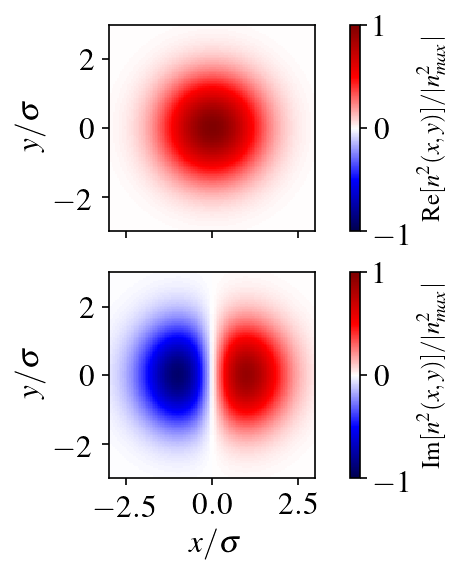

In [9]:
xrange = (-3, 3)
yrange = (-3, 3)
beta = 0.5
sigma = 3
plot_nsquared_3d_junto(xrange, yrange, beta, sigma)

In [10]:
#plot_nsquared_3d(real_part, xrange, yrange, beta, sigma)

In [11]:
#plot_nsquared_3d(imaginary_part, xrange, yrange, beta, sigma)

Interessante que para observarmos uma parte negativa comparável a parte real, precisamos usar um valor de $\beta$ da ordem de $10^6$.

In [12]:
def get_max_spec(beta, sigma, gama, theta):
    num_points = 5000
    omega = np.linspace(0.9, 1.1, num_points)
    spec_dens = norm_spectral_density(omega, theta, sigma, gama, beta)
    imax = np.argmax(spec_dens)
    return omega[imax], spec_dens.max()

In [13]:
def get_omega_max(omega,vec):
    imax = np.argmax(vec)
    return omega[imax]

In [14]:
def get_both_max_spec(beta, sigma, gama, theta):
    num_points = 500
    omega = np.linspace(0.9, 1.1, num_points)
    spec_dens = norm_spectral_density(omega, theta, sigma, gama, beta)
    imin = argrelextrema(spec_dens, np.less)[0]
    if type(imin) != type(1) and len(imin) > 0:
        imin = int(imin)
    spec_dens_left = spec_dens[:imin]
    spec_dens_right = spec_dens[imin:]
    omega_max_left = get_omega_max(omega, spec_dens_left)
    omega_max_right = get_omega_max(omega, spec_dens_right)
    
    return omega_max_left, omega_max_right, spec_dens_left.max(), spec_dens_right.max()

In [15]:
vec_get_max_spec = np.vectorize(get_max_spec)
vec_get_both_max_spec = np.vectorize(get_both_max_spec)

In [16]:
def plot_dif_max_from_mean(beta_range, sigma, gama, theta):
    num_points = 1000
    beta_i, beta_f = beta_range
    beta = np.linspace(beta_i, beta_f, num_points)
    omega_max, spec_dens_max = vec_get_max_spec(beta, sigma, gama, theta)
    omega_med = vec_first_moment(beta, sigma, theta, gama)
    # Isso eh para descobrir qual o omega max e o omega min na variacao
    imax = np.argmax(omega_max)
    imin = np.argmin(omega_max)
    print('O maximo eh: ', beta[imax])
    print('O minimo eh: ', beta[imin])
    fig, (ax1, ax2) = plt.subplots(nrows = 2,ncols = 1,sharex = True, constrained_layout = True)
    ax1.annotate("$\\beta =$ " + str(beta[imax]), (beta[imax],  omega_max[imax]), 
                 xytext=(0.5,0.8), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '-|>'))
    
    ax1.annotate("$\\beta =$ " + str(beta[imin]), (beta[imin],  omega_max[imin]), 
                 xytext=(0.5,0.1), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '-|>'))
    ax1.set_ylabel('$\omega_{c}$')#' - \\left<\\omega \\right>_\\beta |$')
    ax1.plot(beta, omega_max, 'o', markersize = '2')
    
    ax2.plot(beta, spec_dens_max)
    ax2.annotate("Descontinuidade aparece quando\n $S_{max} \\approx 0$", (beta[imin],  spec_dens_max[imin]), 
                 xytext=(0.1,0.5), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '-|>'))
    ax2.set_ylabel('$S_m(\\beta)$')
    ax2.set_xlabel('$\\beta$')
    plt.savefig('grafico_01.eps')

## Comportamento do máximo da distribuição em função de $\beta$

Dado a nossa distribuição, quero entender qual a dependêndia do máximo com nosso parâmetro $\beta$.

O maximo eh:  0.035035035035035036
O minimo eh:  0.03003003003003003


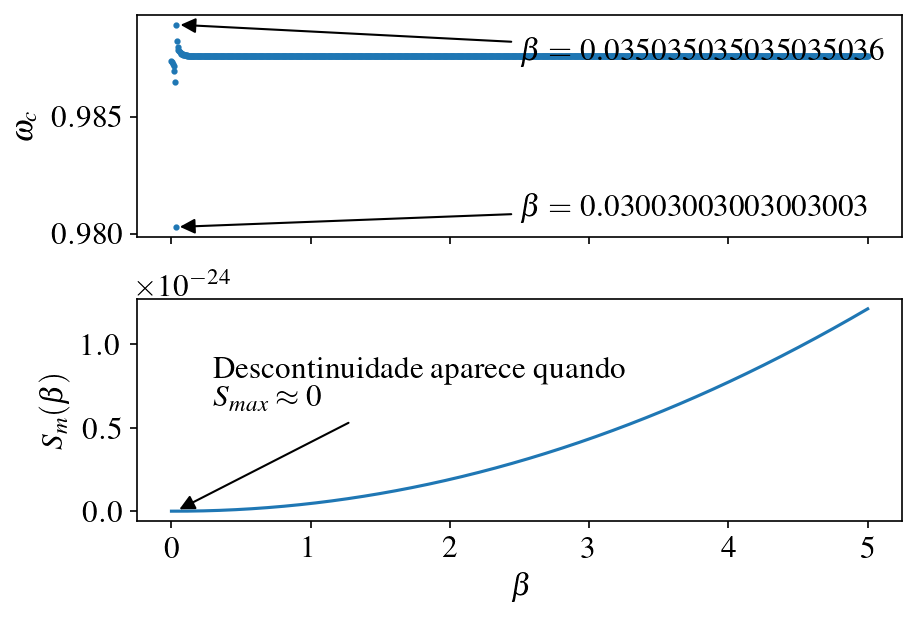

In [17]:
beta_range = (0, 5)
sigma = 6 * np.pi
gama = 0.01
plot_dif_max_from_mean(beta_range, sigma, gama, THETA)

In [18]:
def plot_omega_max_vs_beta(beta_range, sigma, gama, theta):
    num_points = 1000
    beta_i, beta_f = beta_range
    beta = np.linspace(beta_i, beta_f, num_points)
    omega_max, spec_dens_max = vec_get_max_spec(beta, sigma, gama, theta)
    omega_med = vec_first_moment(beta, sigma, theta, gama)
    # Isso eh para descobrir qual o omega max e o omega min na variacao
    imax = np.argmax(omega_max)
    imin = np.argmin(omega_max)
    print('O maximo eh: ', beta[imax])
    print('O minimo eh: ', beta[imin])
    print('O omega para beta = 0 eh:', omega_max[0])
    plt.hlines(omega_max[0],beta_i,beta_f, linestyle = '--')
    plt.annotate('Maximum of the scattered\n spectrum when $\\beta = 0 $ (Hermitian)', (beta[imin],  omega_max[0]), 
                 xytext=(0.3,0.25), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '<|-'))
    plt.hlines(1.0,beta_i,beta_f, linestyle = '--')
    plt.annotate('Maximum of the incident spectrum', (0.05,  1.0), 
                 xytext=(0.3,0.7), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '<|-'))
    plt.ylabel('$\omega_{c}$')#' - \\left<\\omega \\right>_\\beta |$')
    plt.xlabel('$\\beta$')
    plt.plot(beta, omega_max, 'ko', markersize = '2')
    plt.xlim(beta_i,beta_f)
    plt.tight_layout()
    plt.savefig('Omega_max_vs_beta.eps')
    plt.savefig('fig2.eps')

O maximo eh:  0.03083083083083083
O minimo eh:  0.030630630630630633
O omega para beta = 0 eh: 0.987377475495099


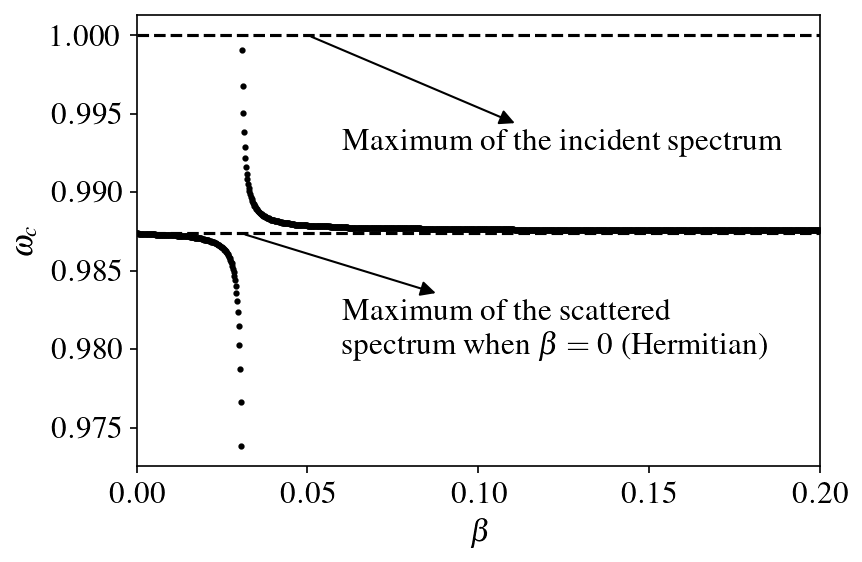

In [19]:
beta_range = (0, 0.2)
sigma = 6 * np.pi
gama = 0.01
plot_omega_max_vs_beta(beta_range, sigma, gama, THETA)

In [20]:
def plot_spectral_density(omega_range, beta, sigma, gama, theta):
    num_points = 1000
    omega_i, omega_f = omega_range
    omega = np.linspace(omega_i,omega_f,num_points)
    fig, ax = plt.subplots()
    style = ['solid', 'dashed','dashdot']
    colors = ['black', 'red', 'blue']
    
    #ax.plot(omega, spectral_density_in(omega,gama), label="$S^{(in)}$", color = 'black')
    for i in range(len(beta)):
        spec_dens = norm_spectral_density(omega, theta, sigma, gama, beta[i])
        label = str(beta[i])
        if len(label) > 6:
            label = label[:6] + '...'
        s_label = '$ S^{(\infty)}$, $\\beta = $ ' + label
        ax.plot(omega, spec_dens, color = colors[i],
                       label=s_label, linestyle = style[i])
    plt.xlim(omega_i, omega_f)
    ax.legend(loc = 'best', frameon = False)
    plt.xlabel("$\omega$")
    plt.ylabel("$S_\\beta(\omega)$")
    plt.tight_layout()
    output_name = 'spectral_density_vs_frequency_beta=' + str(beta) + '.eps'
    plt.savefig(output_name)

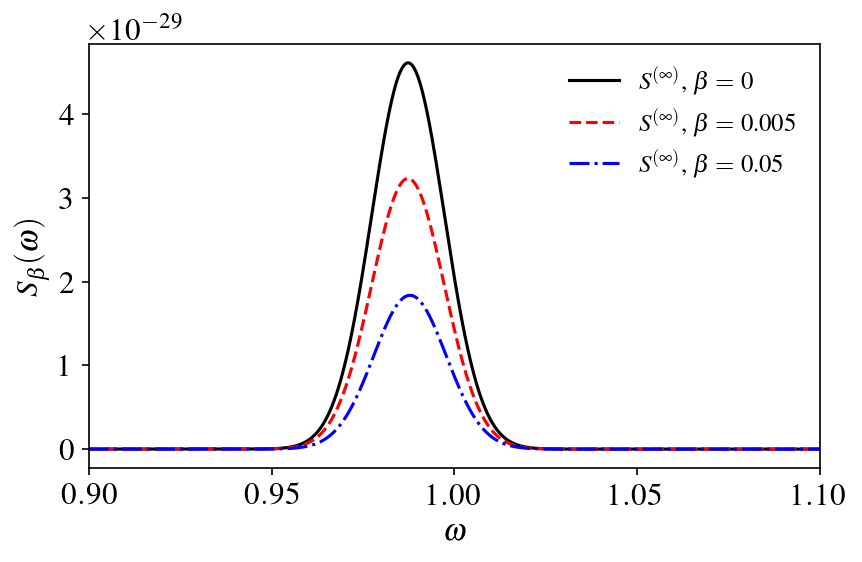

In [21]:
beta = [0, 0.005 ,0.05]
sigma = 6 * np.pi
gama = 0.01
omega_range = (0.9, 1.1)
plot_spectral_density(omega_range, beta,sigma, gama, THETA)

In [22]:
def plot_spectral_density_comparison(omega_range, sigma, gama, theta):
    beta = (0, 0.03079, 0.03054)
    scale = (1,5000,5000)
    num_points = 1000
    omega_i, omega_f = omega_range
    omega = np.linspace(omega_i,omega_f,num_points)
    fig, ax = plt.subplots()
    style = ['solid', 'dashed','dashdot']
    colors = ['black', 'red', 'blue']
    
    spec_dens = [norm_spectral_density(omega, theta, sigma, gama, beta[i])*scale[i] for i in range(len(beta))]
    #ax.plot(omega, spectral_density_in(omega,gama), label="$S^{(in)}$", color = 'black')
    for i in range(len(beta)):
        label = str(beta[i])
        s_label = '$ S^{(\infty)}$, $\\beta = $ ' + label
        ax.plot(omega, spec_dens[i], color = colors[i],
                       label=s_label, linestyle = style[i])
    
    imax1 = np.argmax(spec_dens[1])
    imax2 = np.argmax(spec_dens[2])
    plt.annotate(' $\\times $' + str(scale[1]), (omega[imax1 + 20],  spec_dens[1][imax1 + 20]),
                 xytext=(0.75,0.5), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '<|-'))
    plt.annotate(' $\\times $' + str(scale[2]), (omega[imax2 - 20],  spec_dens[2][imax2 - 20]),
                 xytext=(0.05,0.5), textcoords = 'axes fraction',
                 arrowprops = dict(facecolor = 'black', arrowstyle = '<|-'))
    plt.xlim(omega_i, omega_f)
    ax.legend(loc = 'best', frameon = False)
    plt.xlabel("$\omega$")
    plt.ylabel("$S_\\beta(\omega)$")
    plt.tight_layout()
    output_name = 'spectral_density_vs_frequency_beta=' + str(beta) + '.eps'
    plt.savefig(output_name)
    plt.savefig('fig3.eps')

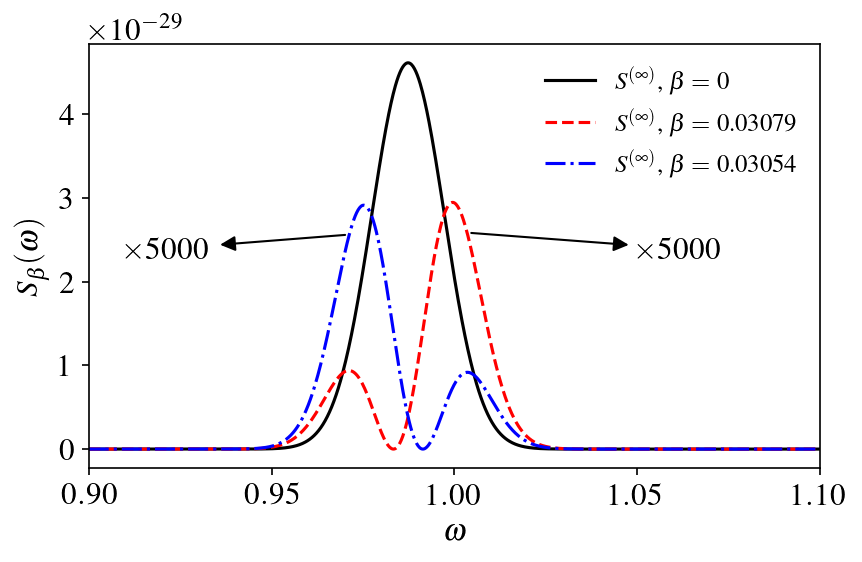

In [23]:
sigma = 6 * np.pi
gama = 0.01
omega_range = (0.9, 1.1)
plot_spectral_density_comparison(omega_range, sigma, gama, THETA)

O gráfico abaixo é a reprodução do gráfico feito pelo professor Paulo no artigo. Note que usando os mesmos parâmetros o gráfico ainda é ligeiramente diferente (no gráfico do artigo para $\sigma = 0.5$ não há intersecção das curvas

In [24]:
def plot_omega_max_movement(beta_range, sigma, gama, theta):
    num_points = 500
    beta_i, beta_f = beta_range
    beta = np.linspace(beta_i, beta_f, num_points)
    omega_max_left, omega_max_right, spec_dens_left, spec_dens_right = vec_get_both_max_spec(beta, sigma, gama, theta)
    fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True)
    ax1.plot(beta, omega_max_left, color = 'black')
    ax1.plot(beta, omega_max_right, color = 'black', linestyle = '--')
    ax1.set_ylabel('$\omega_{c}$')
    ax1.legend(['Left', 'Right'], loc = 'best', frameon= False)
    
    ax2.plot(beta, spec_dens_left, color = 'black')
    ax2.plot(beta, spec_dens_right, color = 'black', linestyle = '--')
    ax2.set_xlabel('$\\beta$')
    ax2.set_ylabel('$S_{m}(\\beta)$')
    ax2.set_xlim(beta_i, beta_f)
    plt.tight_layout()
    plt.savefig('omega_left_and_right_analysis.eps', bbox_inches = 'tight')

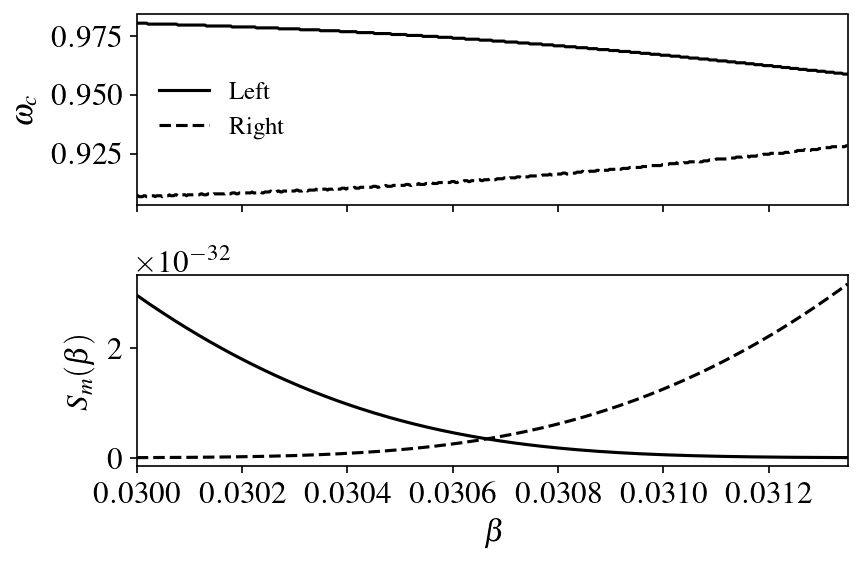

In [25]:
beta_range = (0.030, 0.03135)
sigma = 6 * np.pi
gamma = 0.01
plot_omega_max_movement(beta_range, sigma, gamma, THETA)

In [26]:
def plot_omega_med(beta_range, sigma, gama, theta):
    num_points = 1000
    beta_i, beta_f = beta_range
    fig, ax = plt.subplots()
    beta = np.linspace(beta_i,beta_f,num_points)
    for i in range(len(sigma)):
        for j in range(len(theta)):
            moment = vec_first_moment(beta, sigma[i], theta[j], gama)
            imax = np.argmax(moment)
            imin = np.argmin(moment)
            print("Para sigma = ", sigma[i], "e theta = ", theta[j], 'os extremos ocorrem no par (beta, omega_med):')
            print("MAX:", (beta[imax], moment[imax]))
            print("MIN:", (beta[imin], moment[imin]))
            ax.plot(beta, moment, label = "$\\sigma =$ " + str(sigma[i]) + ',  $\\theta=$ ' + str(theta[j]) + '$^\circ$')

    plt.xlabel("$\\beta$")
    plt.ylabel("$\\langle \\omega \\rangle_\\beta$")
    plt.xlim(beta_i,beta_f)
    ax.legend(loc = "best", frameon = False)
    plt.tight_layout()
    output_name = 'first_moment_by_beta_sigma=' + str(sigma) + '_gama=' + str(gama) + '_theta=' + str(theta) + '.eps'
    plt.savefig(output_name)

Para sigma =  18.84955592153876 e theta =  24.9 os extremos ocorrem no par (beta, omega_med):
MAX: (0.030580580580580583, 1.0021328441139934)
MIN: (0.03023023023023023, 0.9896857366087785)


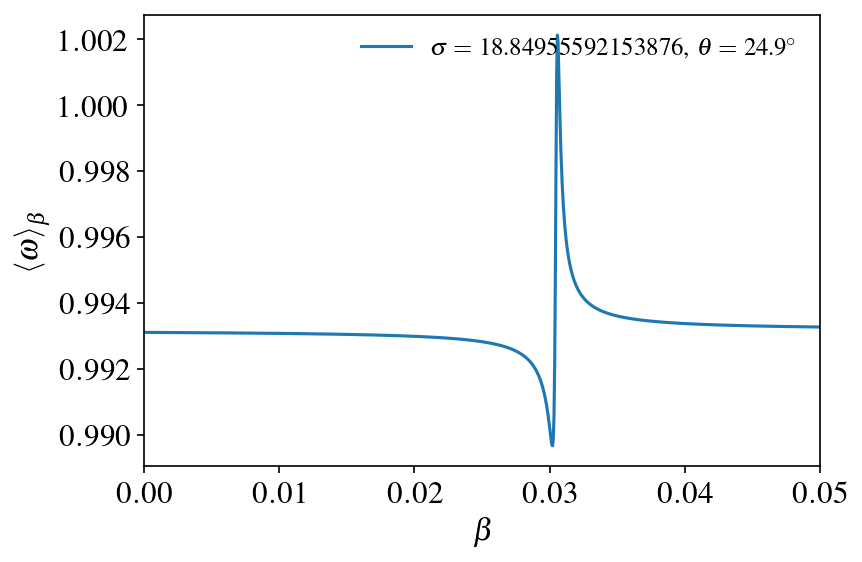

In [27]:
sigma = [6 * np.pi]
gama = 0.01
theta = [THETA]
beta_range = (0,0.05)
plot_omega_med(beta_range, sigma, gama, theta)

Para sigma =  0.5 e theta =  180.0 os extremos ocorrem no par (beta, omega_med):
MAX: (2.017017017017017, 1.0126836478541128)
MIN: (1.981981981981982, 0.9877006570744382)
Para sigma =  0.5 e theta =  200.0 os extremos ocorrem no par (beta, omega_med):
MAX: (2.0820820820820822, 1.0102002296188277)
MIN: (2.042042042042042, 0.9902149441730655)


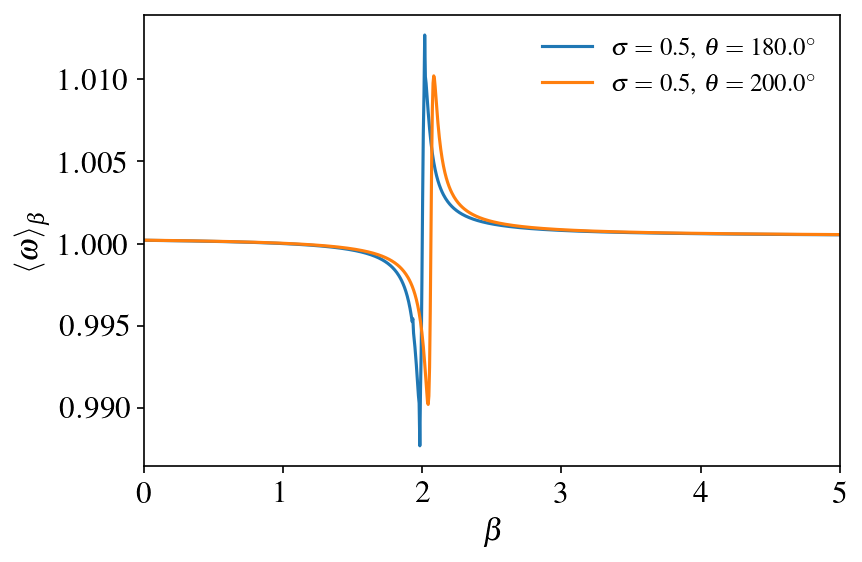

In [28]:
sigma = [0.5]
gama = 0.01
theta = [180.0, 200.0]
beta_range = (0, 5)
plot_omega_med(beta_range, sigma, gama, theta)

In [29]:
def plot_omega_med_3d(beta_range, theta_range, sigma, gama, colormap = 'seismic'):
    num_points = 230
    beta_i, beta_f = beta_range
    theta_i, theta_f = theta_range
    beta = np.linspace(beta_i, beta_f, num_points)
    theta = np.linspace(theta_i, theta_f, num_points)

    beta, theta = np.meshgrid(beta, theta)
    plt.xlabel("$\\beta$")
    plt.ylabel('$\\theta (^{\circ})$')
    moment = vec_first_moment(beta,sigma,theta,gama)
    plt.ylim(theta_i,theta_f)
    plt.xlim(beta_i, beta_f)
    cs = plt.pcolormesh(beta,theta, moment, cmap = colormap, vmin = 0.98)
    cbar = plt.colorbar(cs, label = "$\\langle \\omega \\rangle_\\beta$")
    plt.savefig("first_moment_by_beta_by_theta_sigma=" + str(sigma) +'_gama='+ str(gama) +".eps")

In [30]:
beta_range = (0, 5)
theta_range = (0,360)
sigma = 3.0
gama = 0.01
#plot_omega_med_3d(beta_range, theta_range, sigma, gama)

In [31]:
beta_range = (1.5, 5)
theta_range = (0,360)
sigma = 0.5
gama = 0.01
#plot_omega_med_3d(beta_range, theta_range, sigma, gama)

In [32]:
def g(n,theta, gamma_0, sigma):
    even = [i for i in range(n + 1) if i % 2 == 0]
    result = 0
    gamma_0_O_Lambda_squared = gamma_0 **2 * (2 * (4 *(np.pi * sigma * np.sin(np.radians(theta)* 0.5)))**2)
    Omega = 1/(1 + gamma_0_O_Lambda_squared )
    for k in even:
        result += ss.binom(n,k) * 2**((k + 3)/2) * Omega **(n + (1-k)/2) * gamma_0 ** (k + 1) * ss.gamma((k + 1)/ 2)
        
    return result

In [33]:
def omega_med_analytical(beta, theta, gamma_0, sigma):
    g4 = g(4, theta, gamma_0, sigma)
    g5 = g(5, theta, gamma_0, sigma)
    g6 = g(6, theta, gamma_0, sigma)
    g7 = g(7, theta, gamma_0, sigma)
    B = beta/(8*np.pi) * (2 * (4 *(np.pi * sigma * np.sin(np.radians(theta)* 0.5)))**2)
    return (g5 -B * g6 + B ** 2 * g7)/(g4 -B * g5 + B ** 2 * g6)

In [34]:
def g(n,theta, gamma_0, sigma):
    even = [i for i in range(n + 1) if i % 2 == 0]
    result = 0
    gamma_0_O_Lambda_squared = gamma_0 **2 * (2 * (4 *(np.pi * sigma * np.sin(np.radians(theta)* 0.5)))**2)
    Omega = 1/(1 + gamma_0_O_Lambda_squared )
    Sigma = np.sqrt(gamma_0 ** 2 * Omega)
    for k in even:
        result += ss.binom(n,k) * 2**((k + 3)/2) * Omega **(n -k) * Sigma ** (k + 1) * ss.gamma((k + 1)/ 2)
        
    return result

In [35]:
def func_beta(theta, gamma_0, sigma):
    g4 = g(4, theta, gamma_0, sigma)
    g5 = g(5, theta, gamma_0, sigma)
    g6 = g(6, theta, gamma_0, sigma)
    g7 = g(7, theta, gamma_0, sigma)
    
    Lambda_sqr = 0.5 * (4 * np.pi * sigma * np.sin(np.radians(theta) * 0.5)) ** (-2)
    Beta = (g5 * g6 - g7 * g4 + np.sqrt((g7*g4 - g5 * g6)**2 - 
                                            4 * (g6**2 - g5*g7)*(g5**2 - g6*g4)))/(g6**2 - g5*g7 )
    Beta = Beta * 4 * np.pi * Lambda_sqr
    return Beta

In [36]:
def plot_beta_by_theta(theta_range, gamma_0, sigma):
    num_points = 1000
    theta_i, theta_f = theta_range
    theta = np.linspace(theta_i, theta_f, num_points, endpoint = False)
    plt.plot(func_beta(theta, gamma_0, sigma), theta)
    plt.xlabel('$\\beta$')
    plt.ylabel('$\\theta (^\circ)$')
    plt.xlim(0,5)
    plt.savefig('arco.eps')

In [37]:
#plot_beta_by_theta((10,350), 0.01, 0.5)

In [38]:
def plot_omega_med_3d_overlap_analitical(beta_range, theta_range, sigma, gama, colormap = 'seismic'):
    num_points = 230
    beta_i, beta_f = beta_range
    theta_i, theta_f = theta_range
    beta = np.linspace(beta_i, beta_f, num_points)
    theta = np.linspace(theta_i, theta_f, num_points)

    beta, theta = np.meshgrid(beta, theta)
    plt.xlabel("$\\beta$")
    plt.ylabel('$\\theta (^{\circ})$')
    moment = vec_first_moment(beta,sigma,theta,gama)
    plt.ylim(theta_i,theta_f)
    plt.xlim(beta_i, beta_f)
    cs = plt.pcolormesh(beta,theta, moment, cmap = colormap)
    cbar = plt.colorbar(cs, label = "$\\langle \\omega \\rangle_\\beta$")
# Desconsidero os valores de theta proximos de 0 e proximos de 2 * pi    
    theta = np.linspace(10, 350, num_points)
    plt.plot(func_beta(theta, gama, sigma), theta, color = 'black', label = 'analytical', linestyle = '--')
    plt.legend(loc = "best", frameon = False)
    plt.savefig("first_moment_by_beta_by_theta_analytical_sigma=" + str(sigma) +'_gama='+ str(gama) +".eps")

Tenho que achar denovo o valor do arco.

In [39]:
beta_range = (0, 5)
theta_range = (0,360)
sigma = 0.5
gama = 0.01
#plot_omega_med_3d_overlap_analitical(beta_range, theta_range, sigma, gama)

## $S_\beta(\omega)$ gráfico polar

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


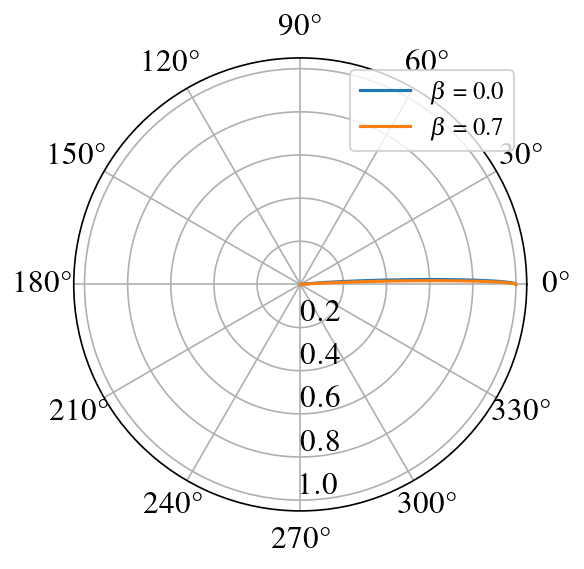

In [40]:
num_points = 50000
omega = 1.0
sigma = 6 * np.pi
gama = 0.01
beta = 0.7
theta_range = (0.0, 180)
theta_i, theta_f = theta_range
theta = np.linspace(theta_i, theta_f, num_points)

#omega_max, _ = vec_get_max_spec(beta, sigma, gama, theta)
ax = plt.subplot(111, polar = True)
ax.plot(np.radians(theta), norm_spectral_density(omega, theta, sigma, gama, 0.0), label = '$\\beta$ = 0.0')
ax.plot(np.radians(theta), norm_spectral_density(omega, theta, sigma, gama, beta), label = '$\\beta$ = ' + str(beta) )
ax.set_rlabel_position(270)
# Mudo a escala dos angulos para multiplos de 30
ax.set_xticks(np.linspace(0,2 * np.pi, 12, endpoint = False))
plt.legend(loc = 'upper right')
plt.savefig('spectral_density_polar.eps')

 O maximo estah em  0.026026026026026022
 O maximo analitico esta em 0.026168385684073623


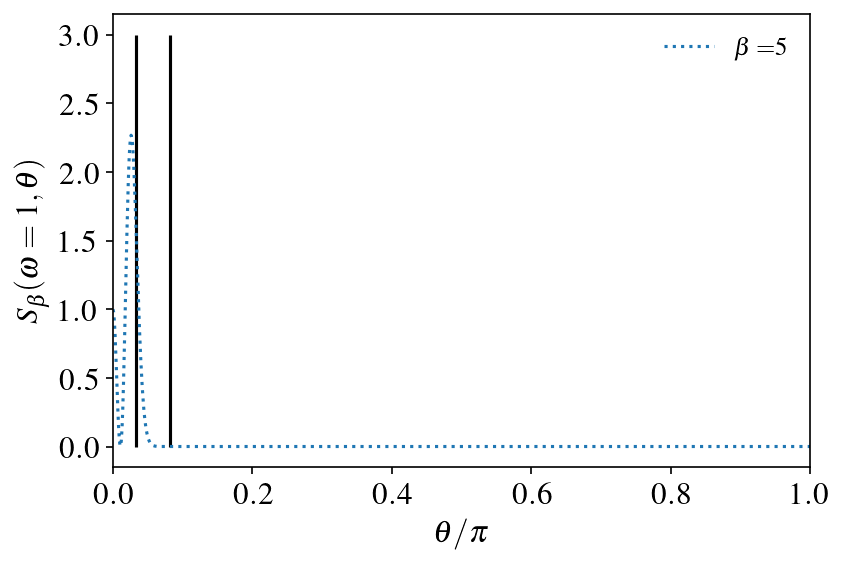

In [90]:
num_points = 1000
omega = 1.0
sigma = 6 * np.pi
gama = 0.01
beta = 0.7
theta_range_degree = (0.0, 180)
theta_range_rad = np.radians(theta_range_degree)

theta_id, theta_fd = theta_range_degree
theta_irad, theta_frad = theta_range_rad
theta_degree = np.linspace(theta_id, theta_fd, num_points)
theta_rad = np.linspace(theta_irad, theta_frad, num_points)
# fig = plt.figure(figsize=(8, 8))

# ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
#plt.plot(theta_rad/ np.pi, norm_spectral_density(omega, theta_degree, sigma, gama, 0.0), label = '$\\beta$ = 0.0')
# plt.plot(theta_rad/np.pi, norm_spectral_density(omega, theta_degree, sigma, gama, beta), label = '$\\beta = $' + str(beta), linestyle = '--')
# beta = 0.9
# plt.plot(theta_rad/np.pi, norm_spectral_density(omega, theta_degree, sigma, gama, beta), label = '$\\beta = $' + str(beta), linestyle = '-.' )
beta = 5
spec_dens = norm_spectral_density(omega, theta_degree, sigma, gama, beta)
imax = np.argmax(spec_dens)
plt.plot(theta_rad/np.pi, spec_dens, label = '$\\beta = $' + str(beta), linestyle = ':')
#ax.set_rlabel_position(270)
plt.xlim(0, 1)
argmax = np.sqrt((1/(2 * sigma ** 2)) * (1 + 1/beta))
theta_min = 2 * np.arcsin(1/np.sqrt(2 * sigma ** 2 * beta))
theta_max = 2 * np.arcsin(argmax)
print(' O maximo estah em ', theta_rad[imax]/np.pi)
print(' O maximo analitico esta em', theta_max/np.pi)
# Mudo a escala dos angulos para multiplos de 30
# ax.set_xticks(np.linspace(0,2 * np.pi, 12, endpoint = False))
plt.vlines(theta_min, 0, 3)
plt.vlines(theta_max, 0, 3)
plt.xlabel('$\\theta/\\pi$')
plt.ylabel('$S_\\beta(\\omega = 1, \\theta)$')
plt.legend(loc = 'best', frameon = False)
# plt.savefig('spectral_density_polar.eps')
plt.savefig('spectral_density_vs_theta.eps')

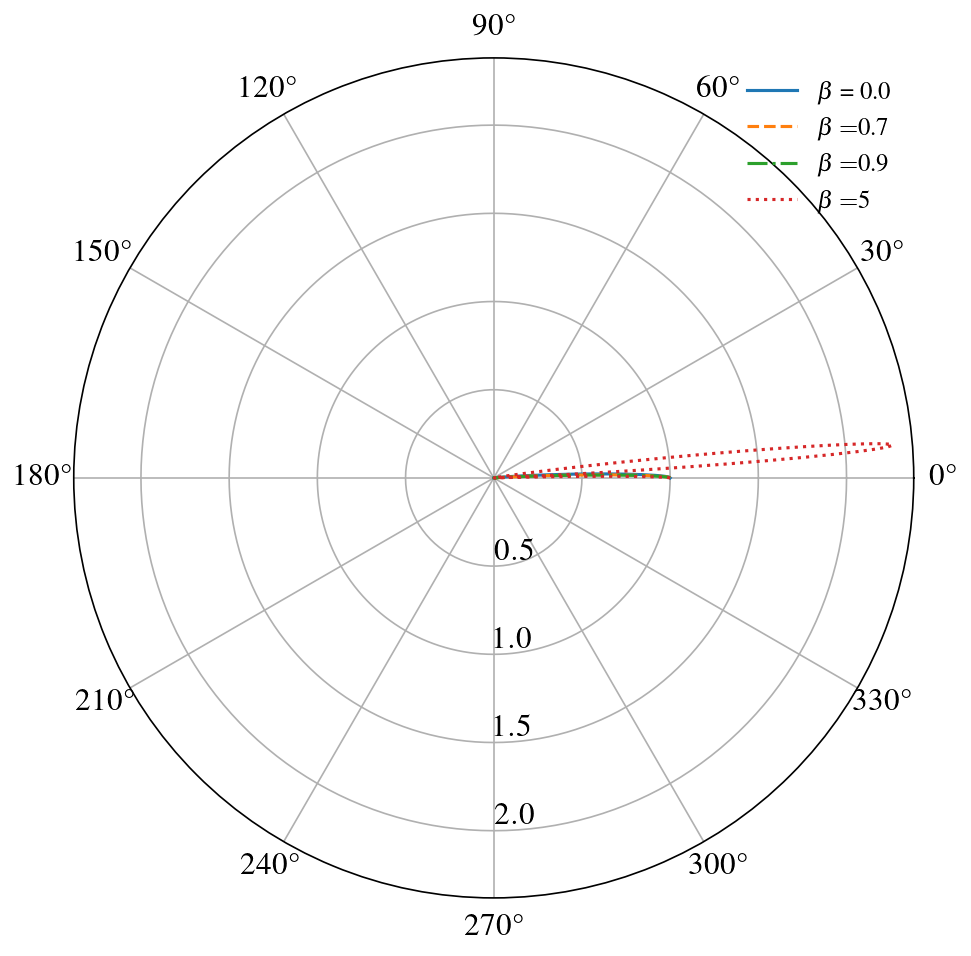

In [42]:
num_points = 1000
omega = 1.0
sigma = 6 * np.pi
gama = 0.01
beta = 0.7
theta_range_degree = (0.0, 180)
theta_range_rad = np.radians(theta_range_degree)

theta_id, theta_fd = theta_range
theta_irad, theta_frad = theta_range_rad
theta_degree = np.linspace(theta_id, theta_fd, num_points)
theta_rad = np.radians(theta_degree)
fig = plt.figure(figsize=(7, 7))

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection = 'polar')
ax.plot(theta_rad, norm_spectral_density(omega, theta_degree, sigma, gama, 0.0), label = '$\\beta$ = 0.0')
ax.plot(theta_rad, norm_spectral_density(omega, theta_degree, sigma, gama, beta), label = '$\\beta = $' + str(beta), linestyle = '--')
beta = 0.9
ax.plot(theta_rad, norm_spectral_density(omega, theta_degree, sigma, gama, beta), label = '$\\beta = $' + str(beta), linestyle = '-.' )
beta = 5
ax.plot(theta_rad, norm_spectral_density(omega, theta_degree, sigma, gama, beta), label = '$\\beta = $' + str(beta), linestyle = ':')
ax.set_rlabel_position(270)
# plt.xlim(0, 0.1)
# Mudo a escala dos angulos para multiplos de 30
ax.set_xticks(np.linspace(0,2 * np.pi, 12, endpoint = False))
# plt.xlabel('$\\theta/\\pi$')
# plt.ylabel('$S_\\beta(\\omega = 1, \\theta)$')
plt.legend(loc = 'best', frameon = False)
# plt.savefig('spectral_density_polar.eps')
plt.savefig('spectral_density_polar.eps')

In [43]:
def plot_spec_dens_3d(beta_range, theta_range, omega, sigma, gamma, colormap = 'seismic'):
    num_points = 200
    beta_i, beta_f = beta_range
    theta_i, theta_f = theta_range
    
    beta = np.linspace(beta_i, beta_f, num_points)
    theta = np.linspace(theta_i, theta_f, num_points)
    
    beta, theta = np.meshgrid(beta, theta)
    
    plt.xlabel("$\\beta$")
    plt.ylabel('$\\theta/ \\pi$')
    spec_dens = norm_spectral_density(omega, theta, sigma, gamma, beta)
    plt.ylim(np.radians(theta_i)/np.pi,np.radians(theta_f)/np.pi)
    plt.xlim(beta_i, beta_f)
    cs = plt.pcolormesh(beta,np.radians(theta)/np.pi, spec_dens, cmap = colormap)
    cbar = plt.colorbar(cs, label = "$S_\\beta$")
    
    plt.savefig('spectral_density_vs_theta_vs_beta.eps')

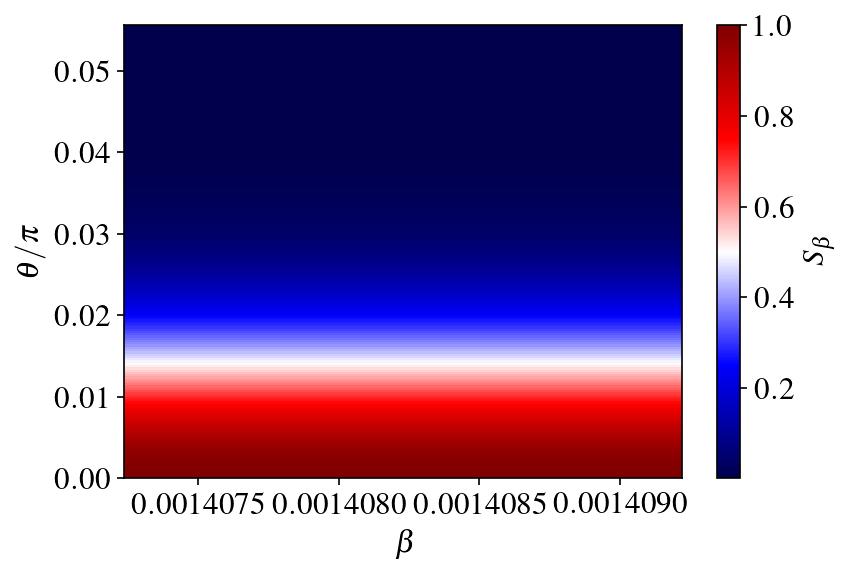

In [54]:
# angulo em graus
theta_range = (0, 10)
omega = 1
sigma = 6 * np.pi
beta_range = (1/(2* sigma **2), 1/(2* sigma **2 - 1))
gamma = 0.01

plot_spec_dens_3d(beta_range, theta_range, omega, sigma, gamma)

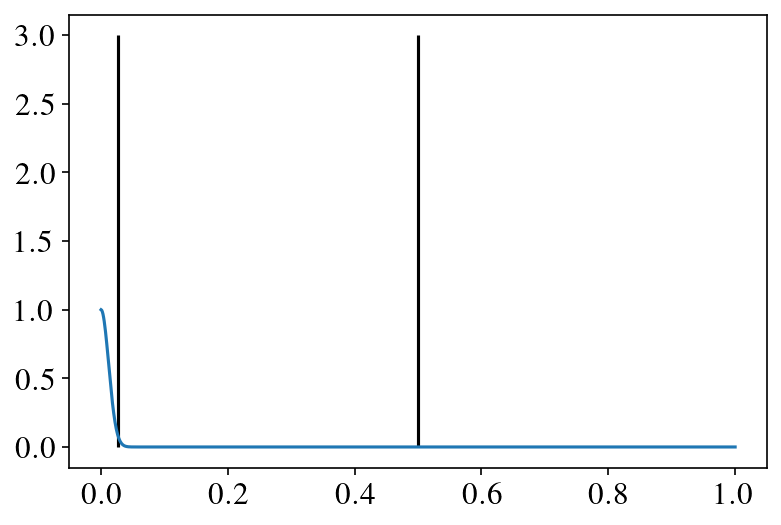

In [97]:
def f(beta, theta,  sigma):
    return np.exp(-4 * sigma ** 2 * (np.sin(theta/2)) ** 2) * (1 - 2 * beta * sigma ** 2 * (np.sin(theta/2)) ** 2) ** 2

theta = np.linspace(0, np.pi, 1000)
sigma = 6 * np.pi
beta = 1/sigma ** 2
s = f(beta,theta ,sigma)

argmin = 1/ np.sqrt(2 * sigma ** 2 * beta)
argmax = np.sqrt((1 + 1/beta)/(2 * sigma ** 2))
theta_min = 2 * np.arcsin(argmin)
plt.plot(theta/np.pi, s)
plt.vlines(theta_max/np.pi, 0, 3)
plt.vlines(theta_min/np.pi, 0, 3)
# plt.xlim(0,0.1)

0.0014082295192111257


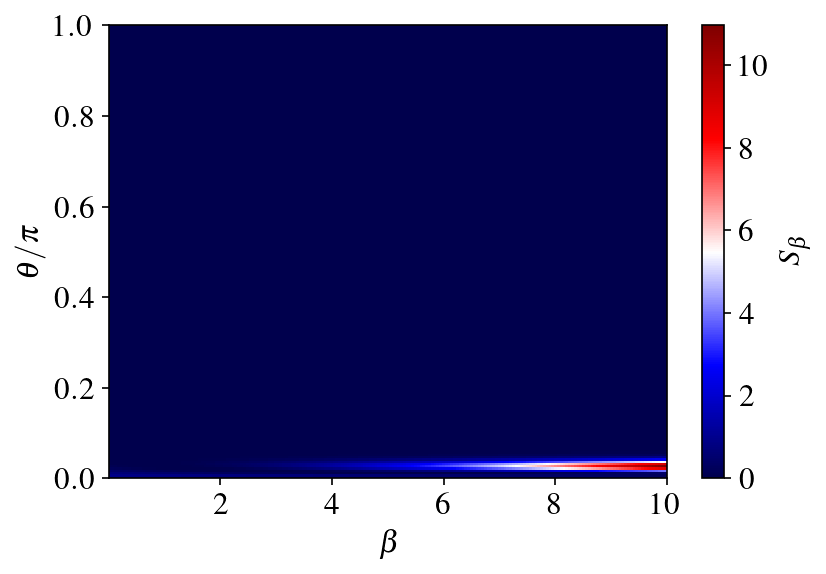

In [106]:
def plot_f():
    num_points = 200
    sigma = 6 * np.pi
    a = 2/(4 * sigma ** 2 - 1)
    print(a)
    beta_i, beta_f = (a, a + 10)
    theta_i, theta_f =  (0, np.pi)
    
    beta = np.linspace(beta_i, beta_f, num_points)
    theta = np.linspace(theta_i, theta_f, num_points)
    
    beta, theta = np.meshgrid(beta, theta)
    
    plt.xlabel("$\\beta$")
    plt.ylabel('$\\theta/ \\pi$')
    spec_dens = f(beta, theta, sigma)
    # plt.ylim(np.radians(theta_i)/np.pi,np.radians(theta_f)/np.pi)
    # plt.xlim(beta_i, beta_f)
    cs = plt.pcolormesh(beta,theta/np.pi, spec_dens, cmap = 'seismic')
    cbar = plt.colorbar(cs, label = "$S_\\beta$")
    
plot_f()